In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np


In [2]:
mpl.rcdefaults()
plt.rc('font', size=12)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=12)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('figure', titlesize=14)  # fontsize of the figure title


In [3]:
from pathlib import Path

In [4]:
BATCH = "008"
# Use .expanduser() to turn "~" into "/home/yourusername"
PARQUETS = Path("~/tesi/sarafu/final_simulations").expanduser()
PICKLED = Path("~/papers/adtxns_paper/pickled_data").expanduser()
SARAFU_PICKLED = PICKLED / "sarafu"

FIGURES = Path("~/papers/adtxns_paper/figures/new").expanduser()


In [5]:
with open(SARAFU_PICKLED / "sarafu.pkl", "rb") as f:
    sarafu = pickle.load(f)



MAIN FIGURE

This exports the metadata to pickle

from preprocessing_utils import *

BATCH ='007'


END = pd.Timestamp('2021-06-15 05:00:30.887568') #*2021-06-15 05:00:30.887568
START = pd.Timestamp('2020-01-25 19:13:17.731529') #*2020-01-25 19:13:17.731529
FIRST_RENEWAL_TIME = 47318.40424 #*seconds from the first activation event in the reference dataset 
NUM_PERIODS = 20 #*free parameter, number of subperiods to divide the transaction record (both sarafu or synthetic data)


simulations_dir = Path("/home/claudio/tesi/sarafu/final_simulations/")
in_dir = simulations_dir / BATCH


metadata_df = load_metadata(in_dir)

metadata_df.to_pickle(PICKLED / BATCH / "metadata.pkl")


In [8]:
metadata = pickle.load(open(PICKLED / BATCH / "metadata.pkl", "rb"))
# metadata

In [36]:
simu_id = metadata.query("s==1 and burstiness==0.25").simulation_id[0]
meta_row = metadata.query("s==1 and burstiness==0.25").iloc[0]
simu_id

'0'

In [ ]:
simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))


In [28]:
from stats_utils import histogram

In [ ]:
keyword = 'final_balances'
s, b = meta_row['s'], meta_row['burstiness']


data_sarafu = sarafu['balance_pivot'].iloc[:,-1]
data_simu = simulation['balance_pivot'].iloc[:,-1]

h1 = histogram(data_sarafu)
h2 = histogram(data_simu)

pickle.dump(h1, open(SARAFU_PICKLED / "histograms" /f"{keyword}.pkl", "wb"))
pickle.dump(h2, open(PICKLED / BATCH / "histograms" /f"{simu_id}_{keyword}.pkl", "wb"))


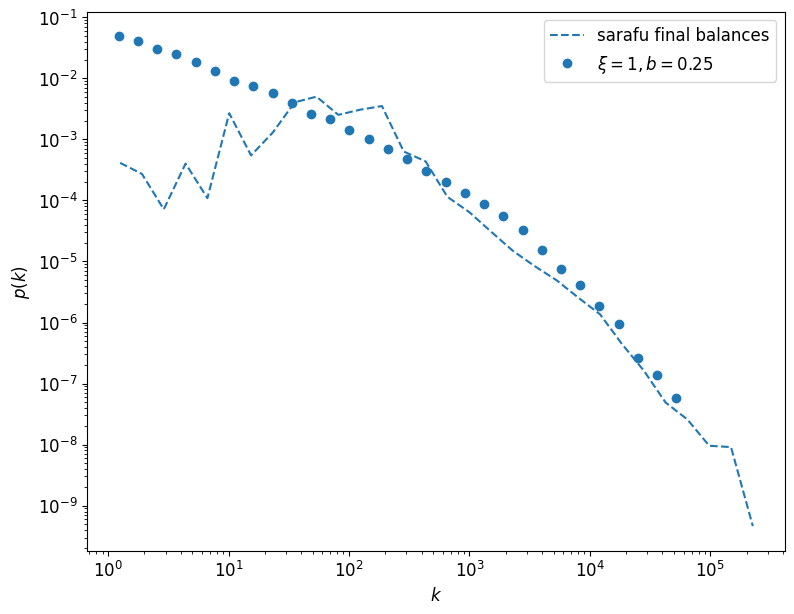

In [ ]:
keyword = 'final_balances'

h1 = pickle.load(open(SARAFU_PICKLED / "histograms" /f"{keyword}.pkl", "rb"))
h2 = pickle.load(open(PICKLED / BATCH / "histograms" /f"{simu_id}_{keyword}.pkl", "rb"))

s, b = meta_row['s'], meta_row['burstiness']

rows, cols = 1,1
fig, ax = plt.subplots(rows, cols, figsize=(9, 7*rows))

ax.plot(h1[0], h1[1], '--', label="sarafu final balances", color = "tab:blue")
ax.plot(h2[0], h2[1], 'o', label=rf"$\xi={s}, b={b}$",color = "tab:blue")

ax.set_xlabel("$k$")
ax.set_ylabel("$p(k)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()


fig.savefig(FIGURES / f"final_balances_s={s}_b={b}.pdf")

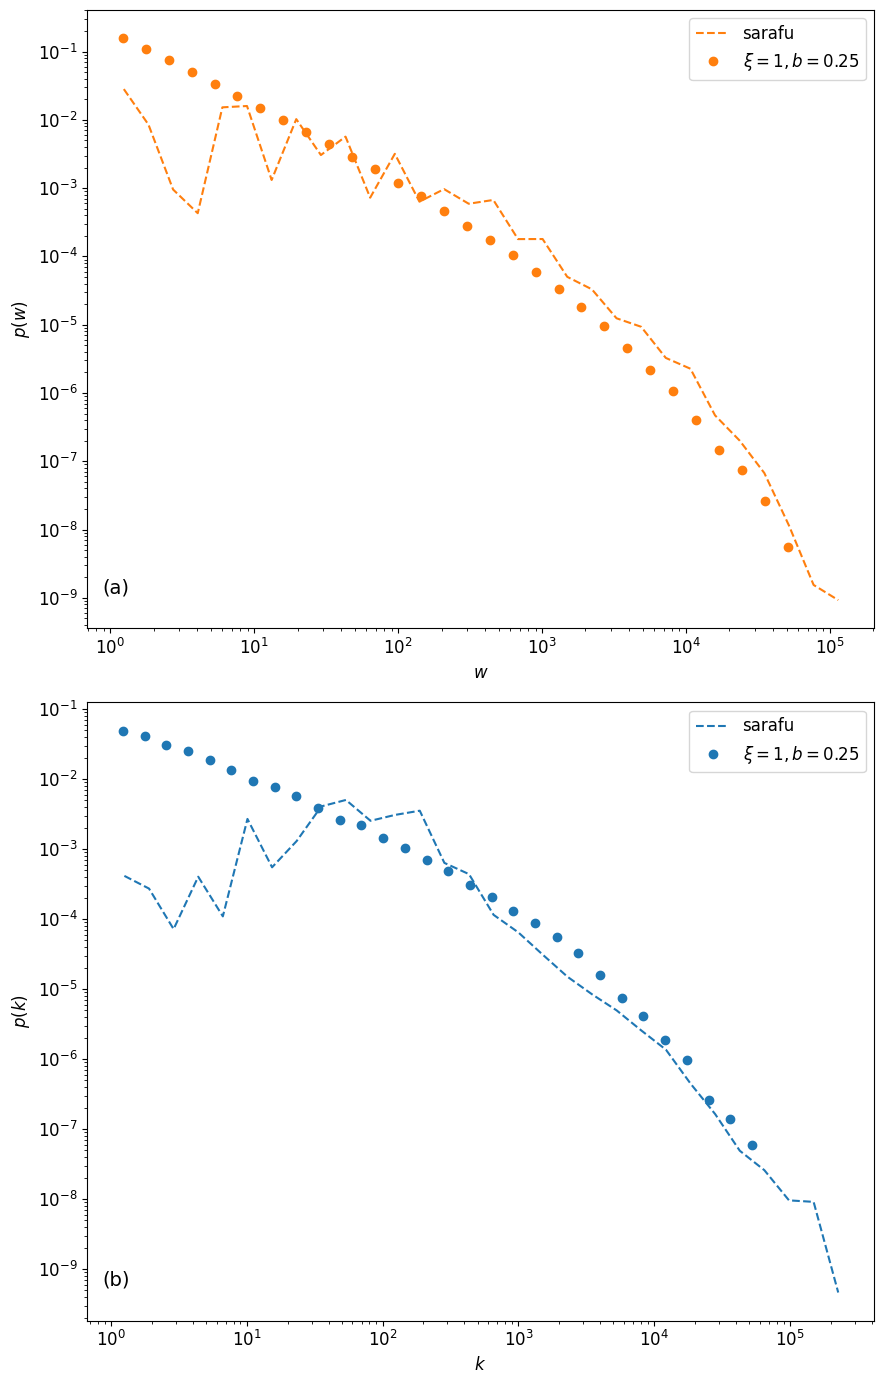

In [67]:
keyword = 'transaction_size'

data_sarafu = sarafu['transactions']['weight']
data_simu = simulation['transactions']['weight']

h1 = histogram(data_sarafu)
h2 = histogram(data_simu)

pickle.dump(h1, open(SARAFU_PICKLED / "histograms" /f"{keyword}.pkl", "wb"))
pickle.dump(h2, open(PICKLED / BATCH / "histograms" /f"{simu_id}_{keyword}.pkl", "wb"))


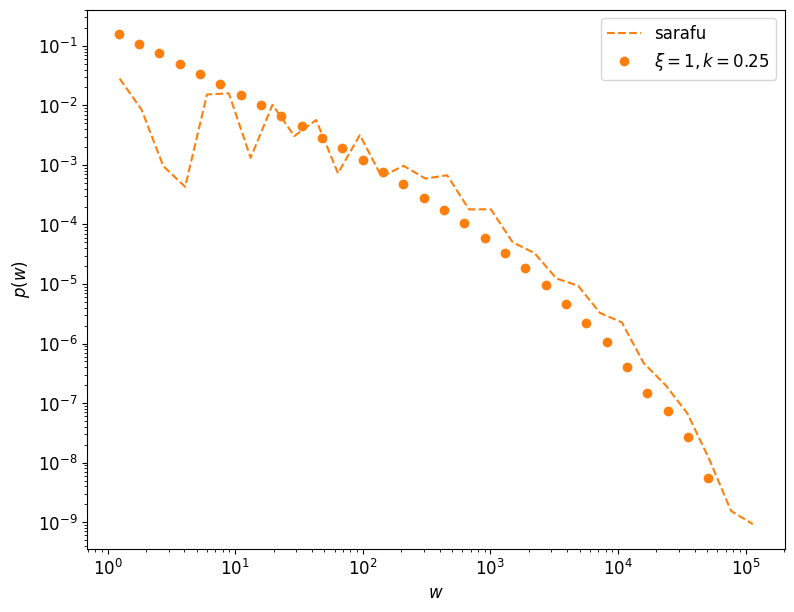

In [82]:
keyword = 'transaction_size'

h1 = pickle.load(open(SARAFU_PICKLED / "histograms" /f"{keyword}.pkl", "rb"))
h2 = pickle.load(open(PICKLED / BATCH / "histograms" /f"{simu_id}_{keyword}.pkl", "rb"))
s, b = meta_row['s'], meta_row['burstiness']

rows, cols = 1,1
fig, ax = plt.subplots(rows, cols, figsize=(9, 7*rows))

ax.plot(h1[0], h1[1], '--', label="sarafu", color = "tab:orange")
ax.plot(h2[0], h2[1], 'o', label=rf"$\xi={s}, k={b}$",color = "tab:orange")

ax.set_xlabel("$w$")
ax.set_ylabel("$p(w)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()

fig.savefig(FIGURES / f"transaction_size_s={s}_b={b}.pdf")
 

In [ ]:
keyword1 = 'transaction_size'
keyword2 = 'final_balances'

h1_ts = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{keyword1}.pkl", "rb"))
h2_ts = pickle.load(open(PICKLED / BATCH / "histograms" / f"{simu_id}_{keyword1}.pkl", "rb"))

h1_fb = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{keyword2}.pkl", "rb"))
h2_fb = pickle.load(open(PICKLED / BATCH / "histograms" / f"{simu_id}_{keyword2}.pkl", "rb"))

s, b = meta_row['s'], meta_row['burstiness']

fig, ax = plt.subplots(2, 1, figsize=(9, 14))

# --- transaction size ---
ax[0].plot(h1_ts[0], h1_ts[1], '--', color="tab:orange", label="sarafu")
ax[0].plot(h2_ts[0], h2_ts[1], 'o', color="tab:orange", label=rf"$\xi={s}, b={b}$")
ax[0].set_xlabel("$w$")
ax[0].set_ylabel("$p(w)$")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].legend()

# --- final balances ---
ax[1].plot(h1_fb[0], h1_fb[1], '--', color="tab:blue", label="sarafu")
ax[1].plot(h2_fb[0], h2_fb[1], 'o', color="tab:blue", label=rf"$\xi={s}, b={b}$")
ax[1].set_xlabel("$k$")
ax[1].set_ylabel("$p(k)$")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].legend()

ax[0].text(
    0.02, 0.05, "(a)",
    transform=ax[0].transAxes,
    fontsize=14,
    va="bottom", ha="left"
)

ax[1].text(
    0.02, 0.05, "(b)",
    transform=ax[1].transAxes,
    fontsize=14,
    va="bottom", ha="left"
)



fig.tight_layout()
fig.savefig(FIGURES / f"bals_and_weights_vertical_s={s}_b={b}.pdf")


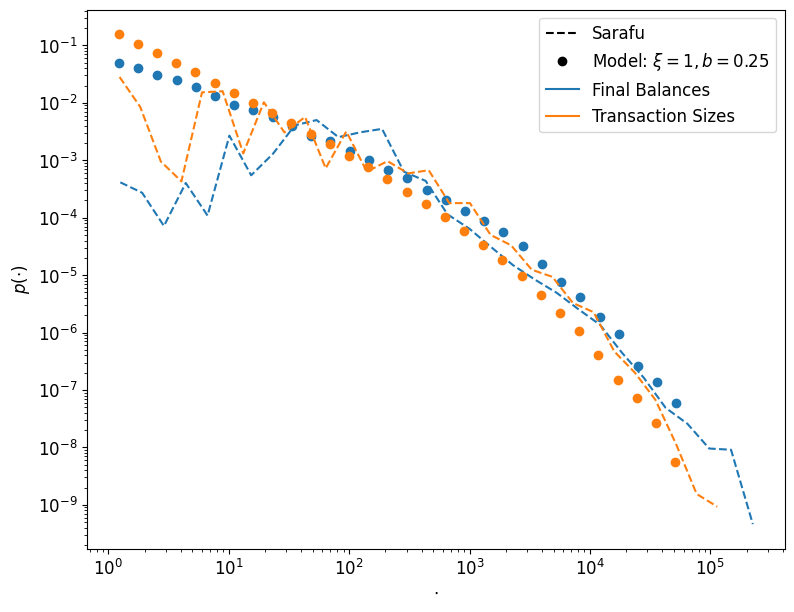

In [78]:
keyword = "final_balances"
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" /f"{keyword}.pkl", "rb"))
h2 = pickle.load(open(PICKLED / BATCH / "histograms" /f"{simu_id}_{keyword}.pkl", "rb"))
keyword = "transaction_size"
h3 = pickle.load(open(SARAFU_PICKLED / "histograms" /f"{keyword}.pkl", "rb"))
h4 = pickle.load(open(PICKLED / BATCH / "histograms" /f"{simu_id}_{keyword}.pkl", "rb"))


rows,cols=1,1
fig, ax = plt.subplots(rows, cols, figsize=(9, 7*rows))
ax.plot(h1[0], h1[1], '--', label="sarafu final balances", color = "tab:blue")
ax.plot(h2[0], h2[1], 'o', label=rf"$\xi={s}, b={b}$",color = "tab:blue")
ax.plot(h3[0], h3[1], '--', label="sarafu transaction size", color = "tab:orange")
ax.plot(h4[0], h4[1], 'o', label=rf"$\xi={s}, b={b}$",color = "tab:orange")

ax.set_xlabel("$\cdot$")
ax.set_ylabel("$p(\cdot)$")
ax.set_xscale("log")
ax.set_yscale("log")
# ax.legend()

from matplotlib.lines import Line2D

legend_elements = [
    # meaning of line styles
    Line2D([0], [0], linestyle='--', color='black', label='Sarafu'),
    Line2D([0], [0], linestyle='None', marker='o', color='black', label=rf"Model: $\xi={s}, b={b}$"),

    # meaning of colors
    Line2D([0], [0], linestyle='-', color='C0', label='Final Balances'),
    Line2D([0], [0], linestyle='-', color='C1', label='Transaction Sizes'),
]

ax.legend(handles=legend_elements)


fig.savefig(FIGURES / f"bal_vs_weight_s={s}_b={b}.pdf")

scatter plots

In [ ]:
# from stats_utils import plot_scatter_kde,plot_scatter_density

In [ ]:
# plot_scatter_density(data.values)
# plt.loglog()

In [48]:
from stats_utils import kde_scatter_estimate, plot_scatter_from_kde, KDEScatterData

In [50]:
columns = ['vol_in','vol_out']
keyword = "-".join(columns)
data = sarafu['agents'][columns].values


In [51]:

k = kde_scatter_estimate(data, bw_method=0.2)   
# k={1:{2:{3:{4:None}}}} 
          # compute once
pickle.dump(k, open(SARAFU_PICKLED / "kde" / f"{keyword}.pkl", "wb"))


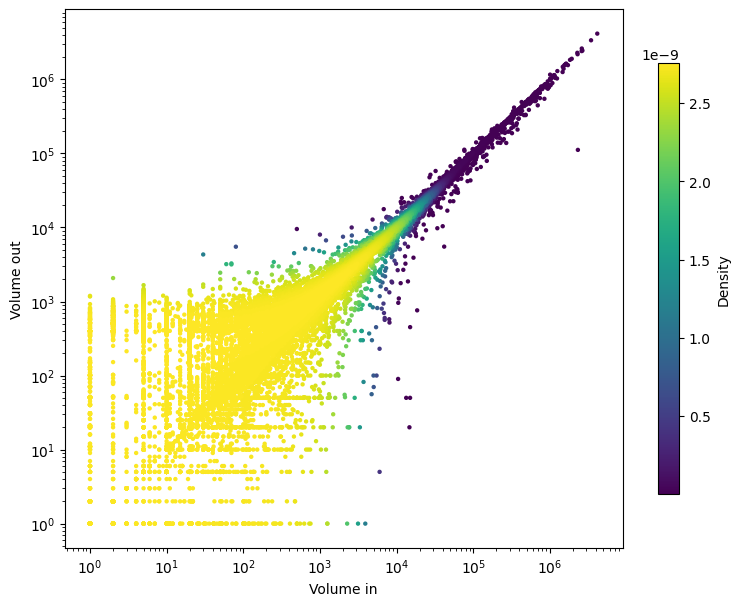

In [56]:
rows, cols = 1,1
fig, ax = plt.subplots(rows, cols, figsize=(9,7))
ax, sc, cb = plot_scatter_from_kde(k, 
                                   ax=ax,
                                   cmap="viridis", 
                                   colorbar_kw={"shrink": 0.8}, 
                                   log_scale=True,
                                   x_label="Volume in", 
                                   y_label="Volume out",
                                   )

In [ ]:
# k = kde_scatter_estimate(data.values, bw_method=0.2)    
#           # compute once
# pickle.dump(k, open(SARAFU_PICKLED / "kde" / f"{keyword}.pkl", "wb"))

In [ ]:
keyword = "txin-txout"
k = pickle.load(open(SARAFU_PICKLED / "kde" / f"{keyword}.pkl", "rb"))

In [ ]:
ax, sc, cb = plot_scatter_from_kde(k, scatter_kw={"s": 5, "alpha": 0.4},log_scale=True)
ax, sc, cb = plot_scatter_from_kde(k, cmap="viridis", colorbar_kw={"shrink": 0.8},log_scale=True)


In [ ]:
data2 = data + np.random.uniform(0, 0.1, size=data.shape)
data1=data

In [ ]:

import matplotlib.colors as mcolors


# compute KDEs once
k1 = kde_scatter_estimate(data1.values)
k2 = kde_scatter_estimate(data2.values)


In [ ]:

# shared normalization (critical)
z_all = np.hstack([k1.z, k2.z])
norm = mcolors.Normalize(vmin=z_all.min(), vmax=z_all.max())

fig, axs = plt.subplots(2, 1, sharex=True, sharey=True)

# plot, no colorbar on individual axes
ax1, sc1, _ = plot_scatter_from_kde(
    k1,
    ax=axs[0],
    norm=norm,
    colorbar=False,
    log_scale=True,
)

ax2, sc2, _ = plot_scatter_from_kde(
    k2,
    ax=axs[1],
    norm=norm,
    colorbar=False,
    log_scale=True,
)

# single shared colorbar
cbar = fig.colorbar(sc1, ax=axs, label="Density")

plt.show()
